In [1]:
import cafe

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

data

In [2]:
fadata = cafe.data.read_pancrease()
fadata

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cafe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

easy trajectory, curve

curve=True, show_milestone_labels=True
curve=True, show_milestone_labels=False
curve=False, show_milestone_labels=True
curve=False, show_milestone_labels=False


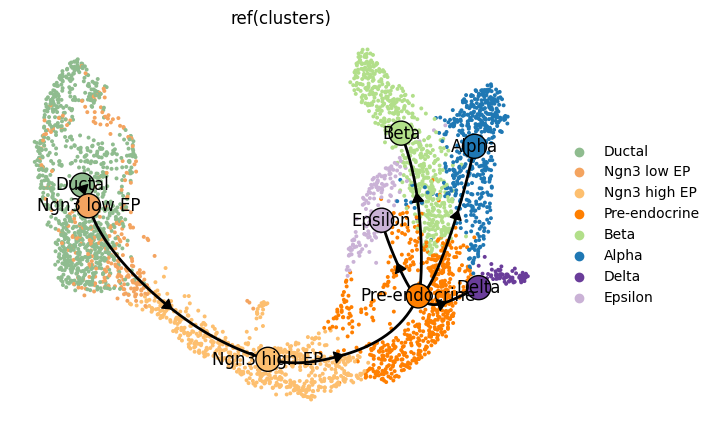

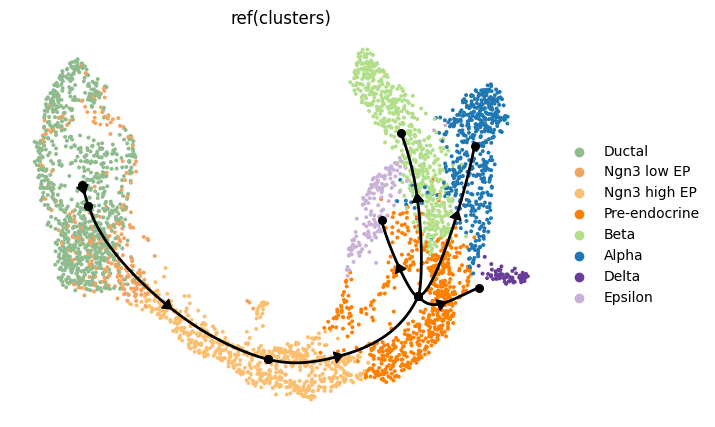

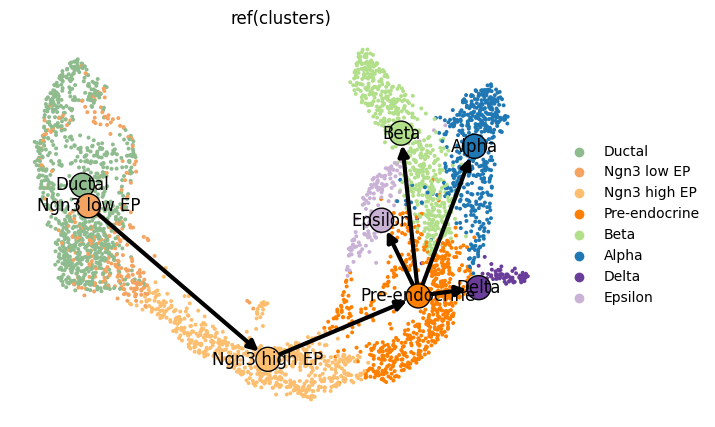

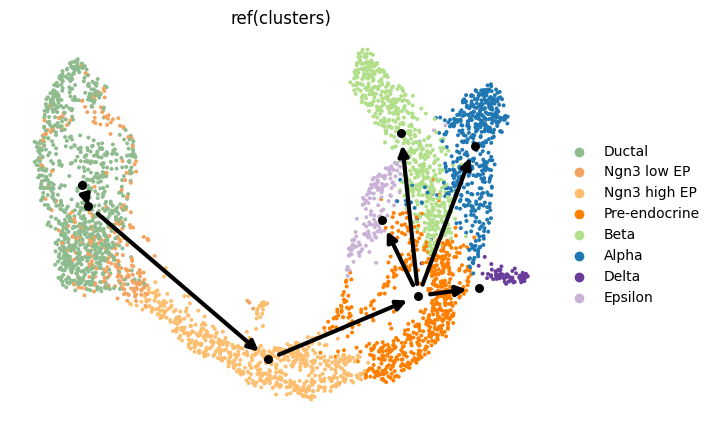

In [3]:
for curve in [True, False]:
    for show_milestone_labels in [True, False]:
        print(f"curve={curve}, show_milestone_labels={show_milestone_labels}")
        cafe.plot.plot_trajectory(
            fadata,
            curve=curve,
            show_milestone_labels=show_milestone_labels,
        )

detail trajectory

array([[<Axes: title={'center': 'ref(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>]],
      dtype=object)

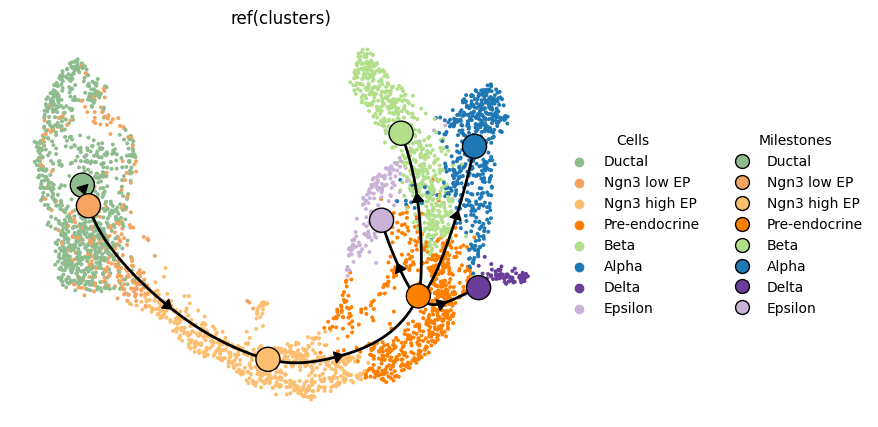

In [4]:
cafe.plot.plot_trajectory(fadata, 
    color_trajectory="black",
    show_milestone_labels=True,
    milestone_legend_loc="right",
    save="img/25.11.19-plot_trajectory_optimization/trajectory_optimization.pdf"
)

展示层级结构

In [5]:
fadata.load_trajectory_dict("scvelo")
fadata

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cafe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

In [6]:
fadata.cafe_dict["trajectory_history_dict"].keys()

dict_keys(['ref', 'scvelo'])

In [8]:

fadata.cafe_dict["trajectory_history_dict"]["ref"].keys()

dict_keys(['milestone_wrapper', 'raw_wrapper_dict', 'trajectory_embedding', 'waypoint_wrapper'])

In [15]:
# 使用 rich 打印树形结构
from rich import print as rprint
from rich.tree import Tree

def dict_to_tree(d, tree=None, name="root", level=None, current_level=0):
    """将嵌套字典转换为 rich Tree
    
    Parameters
    ----------
    d : dict
        要显示的字典
    tree : Tree, optional
        rich Tree 对象
    name : str
        根节点名称
    level : int, optional
        显示的最大层级，None 表示显示所有层级
    current_level : int
        当前层级（内部使用）
    """
    if tree is None:
        tree = Tree(f"[bold]{name}[/bold]")
    
    for key, value in d.items():
        if isinstance(value, dict):
            # 检查是否超过层级限制
            if level is not None and current_level >= level:
                tree.add(f"[cyan]{key}[/cyan] → [dim]dict with {len(value)} keys...[/dim]")
            else:
                branch = tree.add(f"[cyan]{key}[/cyan]")
                dict_to_tree(value, branch, key, level=level, current_level=current_level + 1)
        else:
            # 显示值的类型和简要信息
            type_name = type(value).__name__
            if hasattr(value, 'shape'):
                info = f"[green]{type_name}[/green] shape={value.shape}"
            elif hasattr(value, '__len__') and not isinstance(value, str):
                info = f"[green]{type_name}[/green] len={len(value)}"
            else:
                info = f"[green]{type_name}[/green]: {repr(value)[:50]}"
            tree.add(f"[yellow]{key}[/yellow] → {info}")
    
    return tree

# level=None 显示所有层级，level=1 只显示第一层，level=2 显示前两层...
tree = dict_to_tree(fadata.cafe_dict["trajectory_history_dict"], name="trajectory_history_dict", level=1) # 显示一层结构
rprint(tree)
print("========================================================================================")
tree = dict_to_tree(fadata.cafe_dict["trajectory_history_dict"], name="trajectory_history_dict") # 显示全部结构
rprint(tree)

trajectory_history_dict
├── ref
│   ├── milestone_wrapper → MilestoneWrapper: <cafe.data.fate_milestone_wrapper.MilestoneWrapper
│   ├── raw_wrapper_dict → dict with 0 keys...
│   ├── trajectory_embedding → dict with 1 keys...
│   └── waypoint_wrapper → WaypointWrapper: <cafe.data.fate_waypoint_wrapper.WaypointWrapper o
└── scvelo
    ├── milestone_wrapper → MilestoneWrapper: <cafe.data.fate_milestone_wrapper.MilestoneWrapper
    ├── raw_wrapper_dict → dict with 9 keys...
    ├── trajectory_embedding → dict with 1 keys...
    ├── resource_usage → dict with 3 keys...
    └── waypoint_wrapper → WaypointWrapper: <cafe.data.fate_waypoint_wrapper.WaypointWrapper o

trajectory_history_dict
├── ref
│   ├── milestone_wrapper → MilestoneWrapper: <cafe.data.fate_milestone_wrapper.MilestoneWrapper
│   ├── raw_wrapper_dict
│   ├── trajectory_embedding
│   │   └── X_umap
│   │       ├── wp_segments → DataFrame shape=(212, 9)
│   │       └── milestone_positions → DataFrame shape=(14, 9)
│   └── waypoint_wrapper → WaypointWrapper: <cafe.data.fate_waypoint_wrapper.WaypointWrapper o
└── scvelo
    ├── milestone_wrapper → MilestoneWrapper: <cafe.data.fate_milestone_wrapper.MilestoneWrapper
    ├── raw_wrapper_dict
    │   ├── wrapper_type → str: 'velocity'
    │   ├── velocity → ndarray shape=(3696, 2000)
    │   ├── velocity_graph → csr_matrix shape=(3696, 3696)
    │   ├── velocity_graph_neg → csr_matrix shape=(3696, 3696)
    │   ├── neighbors
    │   │   ├── distances → csr_matrix shape=(3696, 3696)
    │   │   └── connectivities → csr_matrix shape=(3696, 3696)
    │   ├── obs_index → Index shape=(3696,)
    │   ├── var_index → Index shape=(2000,)
    │   ├── resource_usage
    │   │   ├── time → float: 14.0
    │   │   ├── memory → float: 920.62
    │   │   └── cpu → float: 1.32
    │   └── velocity_umap → ndarray shape=(3696, 2)
    ├── trajectory_embedding
    │   └── X_umap
    │       ├── wp_segments → DataFrame shape=(210, 9)
    │       └── milestone_positions → DataFrame shape=(14, 9)
    ├── resource_usage
    │   ├── time → float: 14.0
    │   ├── memory → float: 920.62
    │   └── cpu → float: 1.32
    └── waypoint_wrapper → WaypointWrapper: <cafe.data.fate_waypoint_wrapper.WaypointWrapper o